In [1]:
import numpy as np
import matplotlib.pyplot as plt
import numba as nb
import rasterio
import scipy.ndimage
import scipy.optimize

In [2]:
with rasterio.open("../Dutch Bill Creek-pass2.tif") as file:
    pass2 = file.read(1)[7800:8750, 7750:8500]

In [3]:
connected_NW = np.uint8(0b00000001)
connected_N  = np.uint8(0b00000010)
connected_NE = np.uint8(0b00000100)
connected_E  = np.uint8(0b00001000)
connected_W  = np.uint8(0b00010000)
connected_SW = np.uint8(0b00100000)
connected_S  = np.uint8(0b01000000)
connected_SE = np.uint8(0b10000000)


@nb.jit
def add_edges(nodes, edges, i, j):
    top = i == 0
    bot = i == nodes.shape[0] - 1
    left = j == 0
    right = j == nodes.shape[1] - 1

    if not top and not left and nodes[i - 1, j - 1]:
        edges[i, j] |= connected_NW
    if not top and nodes[i - 1, j]:
        edges[i, j] |= connected_N
    if not top and not right and nodes[i - 1, j + 1]:
        edges[i, j] |= connected_NE

    if not left and nodes[i, j - 1]:
        edges[i, j] |= connected_W
    if not right and nodes[i, j + 1]:
        edges[i, j] |= connected_E

    if not bot and not left and nodes[i + 1, j - 1]:
        edges[i, j] |= connected_SW
    if not bot and nodes[i + 1, j]:
        edges[i, j] |= connected_S
    if not bot and not right and nodes[i + 1, j + 1]:
        edges[i, j] |= connected_SE


@nb.jit
def add_node(nodes, edges, i, j):
    nodes[i, j] = True
    add_edges(nodes, edges, i, j)

    top = i == 0
    bot = i == nodes.shape[0] - 1
    left = j == 0
    right = j == nodes.shape[1] - 1

    if not top and not left and nodes[i - 1, j - 1]:
        add_edges(nodes, edges, i - 1, j - 1)
    if not top and nodes[i - 1, j]:
        add_edges(nodes, edges, i - 1, j)
    if not top and not right and nodes[i - 1, j + 1]:
        add_edges(nodes, edges, i - 1, j + 1)

    if not left and nodes[i, j - 1]:
        add_edges(nodes, edges, i, j - 1)
    if not right and nodes[i, j + 1]:
        add_edges(nodes, edges, i, j + 1)

    if not bot and not left and nodes[i + 1, j - 1]:
        add_edges(nodes, edges, i + 1, j - 1)
    if not bot and nodes[i + 1, j]:
        add_edges(nodes, edges, i + 1, j)
    if not bot and not right and nodes[i + 1, j + 1]:
        add_edges(nodes, edges, i + 1, j + 1)


@nb.jit
def remove_node(nodes, edges, i, j):
    nodes[i, j] = False
    edges[i, j] = 0

    top = i == 0
    bot = i == nodes.shape[0] - 1
    left = j == 0
    right = j == nodes.shape[1] - 1

    if not top and not left and nodes[i - 1, j - 1]:
        edges[i - 1, j - 1] &= ~connected_SE
    if not top and nodes[i - 1, j]:
        edges[i - 1, j] &= ~connected_S
    if not top and not right and nodes[i - 1, j + 1]:
        edges[i - 1, j + 1] &= ~connected_SW

    if not left and nodes[i, j - 1]:
        edges[i, j - 1] &= ~connected_E
    if not right and nodes[i, j + 1]:
        edges[i, j + 1] &= ~connected_W

    if not bot and not left and nodes[i + 1, j - 1]:
        edges[i + 1, j - 1] &= ~connected_NE
    if not bot and nodes[i + 1, j]:
        edges[i + 1, j] &= ~connected_N
    if not bot and not right and nodes[i + 1, j + 1]:
        edges[i + 1, j + 1] &= ~connected_NW


@nb.jit
def edges_from_nodes(nodes):
    edges = np.zeros(nodes.shape, dtype=np.uint8)    
    for i in range(nodes.shape[0]):
        for j in range(nodes.shape[1]):
            if nodes[i, j]:
                add_edges(nodes, edges, i, j)
    return edges

In [4]:
@nb.jit
def queue_push(queue, queue_start_stop, value_i, value_j):
    queue[queue_start_stop[1], 0] = value_i
    queue[queue_start_stop[1], 1] = value_j
    if queue_start_stop[1] + 1 < len(queue):
        queue_start_stop[1] += 1
    else:
        queue_start_stop[1] = 0

@nb.jit
def queue_pop(queue, queue_start_stop):
    value_i = queue[queue_start_stop[0], 0]
    value_j = queue[queue_start_stop[0], 1]
    if queue_start_stop[0] + 1 < len(queue):
        queue_start_stop[0] += 1
    else:
        queue_start_stop[0] = 0
    return value_i, value_j

@nb.jit
def queue_is_empty(queue_start_stop):
    return queue_start_stop[0] == queue_start_stop[1]

@nb.jit
def queue_clear(queue_start_stop):
    queue_start_stop[0] = queue_start_stop[1]

In [5]:
@nb.jit
def set_seeds(edges, seeds, i, j):
    num_seeds = 0

    if edges[i, j] & connected_NW:
        seeds[num_seeds, 0] = i - 1
        seeds[num_seeds, 1] = j - 1
        num_seeds += 1
    if edges[i, j] & connected_N:
        seeds[num_seeds, 0] = i - 1
        seeds[num_seeds, 1] = j
        num_seeds += 1
    if edges[i, j] & connected_NE:
        seeds[num_seeds, 0] = i - 1
        seeds[num_seeds, 1] = j + 1
        num_seeds += 1

    if edges[i, j] & connected_W:
        seeds[num_seeds, 0] = i
        seeds[num_seeds, 1] = j - 1
        num_seeds += 1
    if edges[i, j] & connected_E:
        seeds[num_seeds, 0] = i
        seeds[num_seeds, 1] = j + 1
        num_seeds += 1

    if edges[i, j] & connected_SW:
        seeds[num_seeds, 0] = i + 1
        seeds[num_seeds, 1] = j - 1
        num_seeds += 1
    if edges[i, j] & connected_S:
        seeds[num_seeds, 0] = i + 1
        seeds[num_seeds, 1] = j
        num_seeds += 1
    if edges[i, j] & connected_SE:
        seeds[num_seeds, 0] = i + 1
        seeds[num_seeds, 1] = j + 1
        num_seeds += 1

    return num_seeds

In [6]:
@nb.jit
def remove_if_not_articulation(nodes, edges, seeds, queue, queue_start_stop, touched, touched_start_stop, i, j):
    num_seeds = set_seeds(edges, seeds, i, j)
    remove_node(nodes, edges, i, j)

    if num_seeds == 0:
        # isolated pixel had no neighbors; removing it because we don't want single-node graphs
        return False
    
    target_i = seeds[0, 0]
    target_j = seeds[0, 1]
    touched[target_i, target_j] = touched_start_stop[0]
    touched_start_stop[1] += 1

    for seed_index in range(1, num_seeds):
        seed_i = seeds[seed_index, 0]
        seed_j = seeds[seed_index, 1]

        queue_clear(queue_start_stop)
        queue_push(queue, queue_start_stop, seed_i, seed_j)

        seed_is_connected = False
        while not queue_is_empty(queue_start_stop):
            current_i, current_j = queue_pop(queue, queue_start_stop)

            if touched_start_stop[0] <= touched[current_i, current_j] < touched_start_stop[1]:
                seed_is_connected = True
                break  # this seed is connected to the target; we're done

            if touched[current_i, current_j] == touched_start_stop[1]:
                continue  # already visited this node for this seed

            touched[current_i, current_j] = touched_start_stop[1]

            if edges[current_i, current_j] & connected_NW:
                queue_push(queue, queue_start_stop, current_i - 1, current_j - 1)
            if edges[current_i, current_j] & connected_N:
                queue_push(queue, queue_start_stop, current_i - 1, current_j)
            if edges[current_i, current_j] & connected_NE:
                queue_push(queue, queue_start_stop, current_i - 1, current_j + 1)

            if edges[current_i, current_j] & connected_W:
                queue_push(queue, queue_start_stop, current_i, current_j - 1)
            if edges[current_i, current_j] & connected_E:
                queue_push(queue, queue_start_stop, current_i, current_j + 1)

            if edges[current_i, current_j] & connected_SW:
                queue_push(queue, queue_start_stop, current_i + 1, current_j - 1)
            if edges[current_i, current_j] & connected_S:
                queue_push(queue, queue_start_stop, current_i + 1, current_j)
            if edges[current_i, current_j] & connected_SE:
                queue_push(queue, queue_start_stop, current_i + 1, current_j + 1)

        touched_start_stop[1] += 1

        if not seed_is_connected:
            touched_start_stop[0] = touched_start_stop[1]
            add_node(nodes, edges, i, j)
            return

    touched_start_stop[0] = touched_start_stop[1]
    return


@nb.jit
def skeletonize_impl(nodes, edges, seeds, queue, queue_start_stop, touched, touched_start_stop, i_index, j_index):
    for i, j in zip(i_index, j_index):
        remove_if_not_articulation(nodes, edges, seeds, queue, queue_start_stop, touched, touched_start_stop, i, j)


def skeletonize(bitmap):
    nodes = bitmap.copy()
    edges = edges_from_nodes(nodes)

    j_index, i_index = np.meshgrid(np.arange(nodes.shape[1]), np.arange(nodes.shape[0]))
    i_index = i_index[nodes]
    j_index = j_index[nodes]

    increasing_probability = np.argsort(pass2[i_index, j_index])
    i_index = i_index[increasing_probability]
    j_index = j_index[increasing_probability]

    seeds = np.empty((8, 2), dtype=np.int64)

    queue_max_size = len(increasing_probability)
    queue = np.empty((queue_max_size, 2), dtype=np.int64)  # it's a queue of i, j pairs
    queue_start_stop = np.zeros(2, dtype=np.int64)

    touched = np.zeros(nodes.shape, dtype=np.int64)
    touched_start_stop = np.asarray([1, 1], dtype=np.int64)

    skeletonize_impl(nodes, edges, seeds, queue, queue_start_stop, touched, touched_start_stop, i_index, j_index)
    return nodes, edges

In [7]:
%%time

# dominated by compilation time
_ = skeletonize(pass2 > 0.01)

CPU times: user 1.46 s, sys: 426 ms, total: 1.89 s
Wall time: 1.89 s


In [8]:
%%time

# just runtime
nodes, _ = skeletonize(pass2 > 0.01)

CPU times: user 105 ms, sys: 1.87 ms, total: 107 ms
Wall time: 106 ms


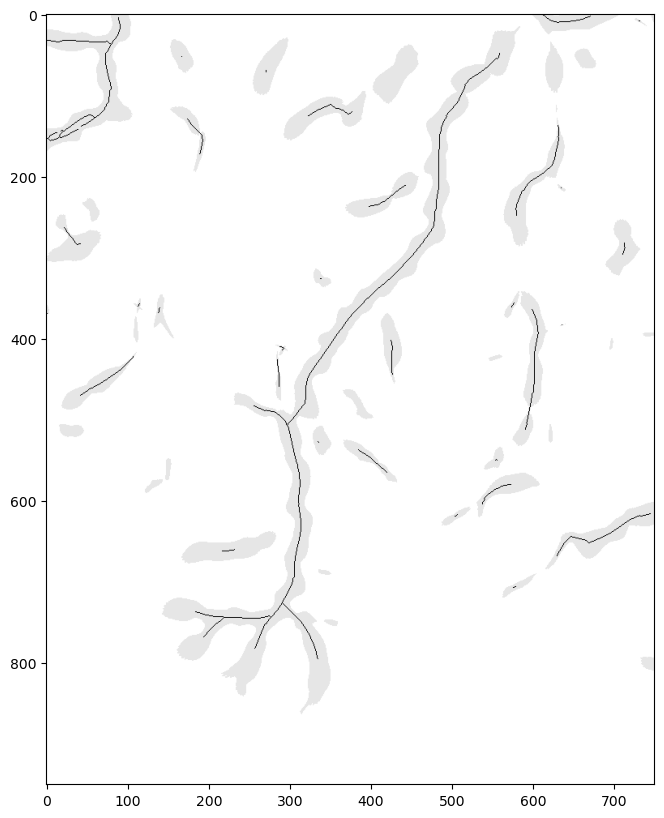

In [9]:
fig, ax = plt.subplots(figsize=(20, 10))

ax.imshow(nodes, vmin=0, vmax=1, cmap="gray_r")
ax.imshow(pass2 > 0.01, vmin=0, vmax=1, cmap="gray_r", alpha=0.1)

None